## Import libraries and load the dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("Amazon.csv")
df = pd.DataFrame(data)
print("First Five Records:")
print(df.head())

First Five Records:
      OrderID   OrderDate  CustomerID   CustomerName ProductID  \
0  ORD0000001  31-01-2023  CUST001504  Vihaan Sharma    P00014   
1  ORD0000002  30-12-2023  CUST000178    Pooja Kumar    P00040   
2  ORD0000003  10-05-2022  CUST047516    Sneha Singh    P00044   
3  ORD0000004  18-07-2023  CUST030059   Vihaan Reddy    P00041   
4  ORD0000005  04-02-2023  CUST048677  Aditya Kapoor    P00029   

           ProductName        Category       Brand  Quantity  UnitPrice  \
0           Drone Mini           Books   BrightLux         3     106.59   
1           Microphone  Home & Kitchen  UrbanStyle         1     251.37   
2  Power Bank 20000mAh        Clothing  UrbanStyle         3      35.03   
3       Webcam Full HD  Home & Kitchen      Zenith         5      33.58   
4              T-Shirt        Clothing    KiddoFun         2     515.64   

   Discount    Tax  ShippingCost  TotalAmount     PaymentMethod OrderStatus  \
0      0.00   0.00          0.09       319.86        

 ## Dataset Overview

In [4]:
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
display(df.describe())


Dataset Shape:
Rows: 100000
Columns: 20

Column Names:
Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

Data Types:
OrderID           object
OrderDate         object
CustomerID        object
CustomerName      object
ProductID         object
ProductName       object
Category          object
Brand             object
Quantity           int64
UnitPrice        float64
Discount         float64
Tax              float64
ShippingCost     float64
TotalAmount      float64
PaymentMethod     object
OrderStatus       object
City              object
State             object
Country           object
SellerID          object
dtype: object

Statistical Summary:


,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


## KPI Analysis

Calculate the following Key Performance Indicators (KPIs):

- Total Sales
- Total Profit *(Assumed as 20% of Total Sales)*
- Total Orders
- Average Sales
- Average Profit
- Maximum Sales
- Minimum Sales

**Note:** Since the original dataset does not contain a `Profit` column, Profit is estimated as **20% of Total Sales** for analytical purposes.

In [5]:
# Create Profit column (20% of Total Sales)
df['Profit'] = df['TotalAmount'] * 0.20

# Calculate KPIs
total_sales = df['TotalAmount'].sum()
total_profit = df['Profit'].sum()
total_orders = df['OrderID'].nunique()
average_sales = df['TotalAmount'].mean()
average_profit = df['Profit'].mean()
maximum_sales = df['TotalAmount'].max()
minimum_sales = df['TotalAmount'].min()

# Display KPIs
print("========== KEY PERFORMANCE INDICATORS ==========\n")
print(f"Total Sales      : ₹{total_sales:,.2f}")
print(f"Total Profit     : ₹{total_profit:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Average Sales    : ₹{average_sales:,.2f}")
print(f"Average Profit   : ₹{average_profit:,.2f}")
print(f"Maximum Sales    : ₹{maximum_sales:,.2f}")
print(f"Minimum Sales    : ₹{minimum_sales:,.2f}")

========== KEY PERFORMANCE INDICATORS ==========

Total Sales      : ₹91,825,647.92
Total Profit     : ₹18,365,129.58
Total Orders     : 100,000
Average Sales    : ₹918.26
Average Profit   : ₹183.65
Maximum Sales    : ₹3,534.98
Minimum Sales    : ₹4.27


##  Sales Analysis by State
This analysis helps identify the highest and lowest revenue-generating states, enabling management to evaluate regional sales performance and plan targeted business strategies.

In [28]:
state_sales = (
    df.groupby('State', as_index=False)['TotalAmount']
      .sum()
      .sort_values(by='TotalAmount', ascending=False)
)

# Rename column
state_sales.rename(columns={'TotalAmount': 'Total Sales'}, inplace=True)

# Format currency
state_sales['Total Sales'] = state_sales['Total Sales'].map(lambda x: f"₹{x:,.2f}")

# Display the result
print("========== TOTAL SALES BY STATE ==========\n")
display(state_sales)

========== TOTAL SALES BY STATE ==========



,State,Total Sales
11,TX,"₹22,862,540.54"
1,CA,"₹18,231,196.79"
7,NC,"₹4,747,701.73"
12,WA,"₹4,660,962.17"
10,PA,"₹4,650,673.88"
2,CO,"₹4,638,498.97"
5,IL,"₹4,632,847.44"
9,OH,"₹4,615,442.32"
6,IN,"₹4,609,048.43"
4,FL,"₹4,597,177.27"


## Sales Analysis by Category
This analysis helps identify the highest revenue-generating categories, allowing the business to focus on product segments that contribute the most to overall sales.

In [26]:
category_sales = (
    df.groupby('Category', as_index=False)['TotalAmount']
      .sum()
      .sort_values(by='TotalAmount', ascending=False)
)

# Rename column
category_sales.rename(columns={'TotalAmount': 'Total Sales'}, inplace=True)

# Format currency
category_sales['Total Sales'] = category_sales['Total Sales'].map(lambda x: f"₹{x:,.2f}")

print("========== TOTAL SALES BY CATEGORY ==========\n")
display(category_sales)

========== TOTAL SALES BY CATEGORY ==========



,Category,Total Sales
2,Electronics,"₹15,584,217.18"
4,Sports & Outdoors,"₹15,345,571.88"
0,Books,"₹15,261,837.01"
1,Clothing,"₹15,253,397.50"
5,Toys & Games,"₹15,216,684.99"
3,Home & Kitchen,"₹15,163,939.36"


## Sales Analysis by Sub-Category (Product)
This analysis helps identify the highest revenue-generating products, enabling the business to optimize inventory management and focus on top-selling items.

In [24]:
# Group data by Product and calculate total sales
product_sales = (
    df.groupby('ProductName', as_index=False)['TotalAmount']
      .sum()
      .sort_values(by='TotalAmount', ascending=False)
)
product_sales['TotalAmount'] = product_sales['TotalAmount'].map(lambda x: f"₹{x:,.2f}")
print("========== TOTAL SALES BY PRODUCT ==========\n")
display(product_sales)

========== TOTAL SALES BY PRODUCT ==========



,ProductName,TotalAmount
25,Memory Card 128GB,"₹1,935,138.40"
22,LED Desk Lamp,"₹1,921,948.41"
24,Mechanical Keyboard,"₹1,906,963.54"
13,Electric Kettle,"₹1,905,751.79"
39,Smartwatch,"₹1,901,275.59"
11,Dress Shirt,"₹1,896,765.36"
44,Water Bottle,"₹1,895,467.95"
16,Gaming Mouse,"₹1,895,103.98"
21,Kids Toy Car,"₹1,891,082.43"
20,Jeans,"₹1,882,591.82"


## Top 5 Customers
This analysis helps identify high-value customers who contribute significantly to overall revenue and supports customer retention strategies.

In [23]:
top_customers = (
    df.groupby('CustomerName', as_index=False)['TotalAmount']
      .sum()
      .sort_values(by='TotalAmount', ascending=False)
      .head(5)
)
top_customers['TotalAmount'] = top_customers['TotalAmount'].map(lambda x: f"₹{x:,.2f}")
print("========== TOP 5 CUSTOMERS ==========\n")
display(top_customers)

========== TOP 5 CUSTOMERS ==========



,CustomerName,TotalAmount
92,Pooja Kapoor,"₹547,832.64"
178,Vihaan Singh,"₹526,675.89"
98,Pooja Singh,"₹516,451.45"
51,Kabir Joshi,"₹515,361.68"
10,Aditya Gupta,"₹515,005.09"


## Product Quantity Analysis
This analysis helps identify the most frequently purchased products, enabling better inventory planning and demand forecasting.

In [16]:
# Group data by Product and calculate total quantity sold
product_quantity = (
    df.groupby('ProductName', as_index=False)['Quantity']
      .sum()
      .sort_values(by='Quantity', ascending=False)
)
print("========== TOTAL QUANTITY SOLD BY PRODUCT ==========\n")
display(product_quantity)

========== TOTAL QUANTITY SOLD BY PRODUCT ==========



,ProductName,Quantity
22,LED Desk Lamp,6344
44,Water Bottle,6275
25,Memory Card 128GB,6240
35,Router,6202
5,Board Game,6200
26,Microphone,6196
16,Gaming Mouse,6170
13,Electric Kettle,6165
24,Mechanical Keyboard,6161
43,Vacuum Cleaner,6139


## Payment Mode Analysis
This analysis helps understand customer payment preferences and can support decisions related to payment offers and promotional campaigns.

In [18]:
payment_analysis = (
    df.groupby('PaymentMethod', as_index=False)['OrderID']
      .count()
      .sort_values(by='OrderID', ascending=False)
)
payment_analysis.rename(columns={'OrderID': 'Number of Orders'}, inplace=True)
print("========== PAYMENT MODE ANALYSIS ==========\n")
display(payment_analysis)

========== PAYMENT MODE ANALYSIS ==========



,PaymentMethod,Number of Orders
2,Credit Card,35038
3,Debit Card,20024
5,UPI,15066
0,Amazon Pay,15017
4,Net Banking,9927
1,Cash on Delivery,4928


## Monthly Sales Trend Analysis
This analysis helps identify seasonal trends, peak sales months, and periods of lower sales, enabling better business planning and inventory management.

In [21]:
# Q12. Monthly Sales Trend

# Convert OrderDate to datetime (if not already)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Extract Month Name
df['Month'] = df['OrderDate'].dt.month_name()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df['Month'] = pd.Categorical(df['Month'],
                             categories=month_order,
                             ordered=True)

# Calculate monthly sales
monthly_sales = (
    df.groupby('Month', as_index=False)['TotalAmount']
      .sum()
)

# Rename column
monthly_sales.rename(columns={'TotalAmount': 'Total Sales'}, inplace=True)

# Format currency
monthly_sales['Total Sales'] = monthly_sales['Total Sales'].map(lambda x: f"₹{x:,.2f}")

print("========== MONTHLY SALES TREND ==========\n")
display(monthly_sales)

========== MONTHLY SALES TREND ==========



C:\Users\Asus\AppData\Local\Temp\ipykernel_14508\3878881220.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_14508\3878881220.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Month', as_index=False)['TotalAmount']


,Month,Total Sales
0,January,"₹7,883,801.27"
1,February,"₹6,931,724.49"
2,March,"₹7,766,527.73"
3,April,"₹7,646,203.22"
4,May,"₹7,864,283.27"
5,June,"₹7,654,636.75"
6,July,"₹7,737,925.51"
7,August,"₹7,890,598.37"
8,September,"₹7,558,970.85"
9,October,"₹7,654,243.32"


## State-wise Category Sales Analysis
This multi-level analysis helps compare category performance across different states and supports regional business strategy and inventory planning.

In [22]:
state_category_sales = (
    df.groupby(['State', 'Category'], as_index=False)['TotalAmount']
      .sum()
      .sort_values(by=['State', 'TotalAmount'], ascending=[True, False])
)

# Rename column
state_category_sales.rename(columns={'TotalAmount': 'Total Sales'}, inplace=True)

# Format currency
state_category_sales['Total Sales'] = state_category_sales['Total Sales'].map(lambda x: f"₹{x:,.2f}")

print("========== STATE-WISE CATEGORY SALES ==========\n")
display(state_category_sales)

========== STATE-WISE CATEGORY SALES ==========



,State,Category,Total Sales
5,AZ,Toys & Games,"₹839,973.27"
0,AZ,Books,"₹793,211.33"
2,AZ,Electronics,"₹747,955.37"
3,AZ,Home & Kitchen,"₹737,616.34"
4,AZ,Sports & Outdoors,"₹694,318.06"
...,...,...,...
75,WA,Home & Kitchen,"₹809,448.28"
76,WA,Sports & Outdoors,"₹807,282.60"
73,WA,Clothing,"₹747,668.70"
77,WA,Toys & Games,"₹711,514.12"


# Data Visualization

## Bar Chart: Sales by State
This visualization helps compare the sales performance of different states and quickly identify the highest and lowest revenue-generating regions.

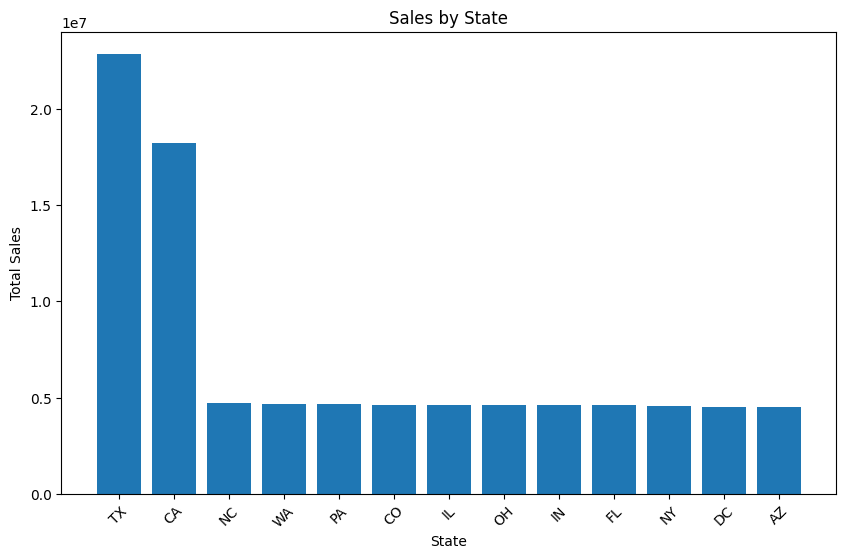

In [29]:
state_sales = (
    df.groupby('State', as_index=False)['TotalAmount']
      .sum()
      .sort_values(by='TotalAmount', ascending=False)
)

# Plot bar chart
plt.figure(figsize=(10,6))

plt.bar(state_sales['State'], state_sales['TotalAmount'])

plt.title('Sales by State')
plt.xlabel('State')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

## Horizontal Bar Chart – Top 10 Products by Sales
It helps identify the best-selling products, enabling the business to prioritize inventory, marketing efforts, and promotional strategies for high-performing items.

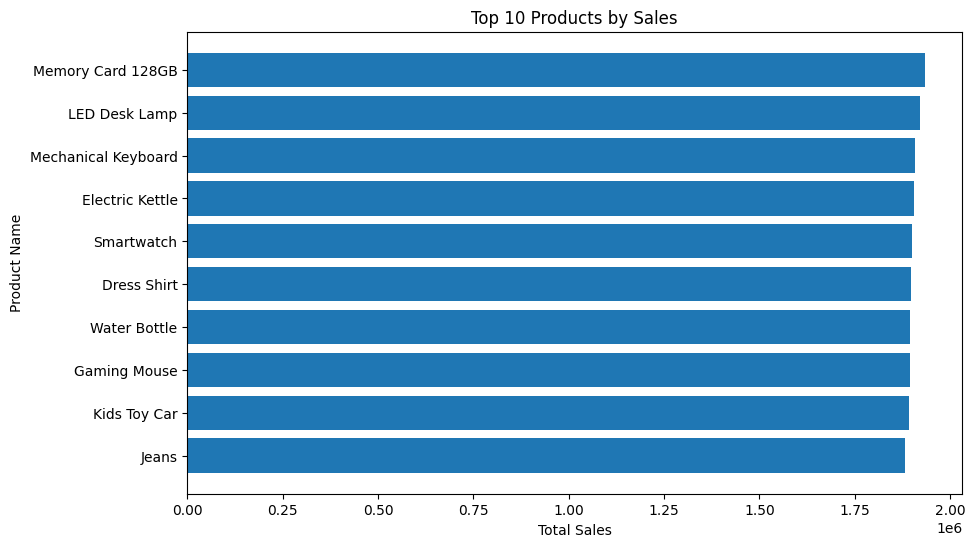

In [33]:
top10_products = (
    df.groupby('ProductName', as_index=False)['TotalAmount']
      .sum()
      .sort_values(by='TotalAmount', ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(top10_products['ProductName'], top10_products['TotalAmount'])

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

# Highest-selling product at the top
plt.gca().invert_yaxis()

plt.show()

## Pie Chart – Sales by Category
It provides a quick overview of category-wise revenue distribution.

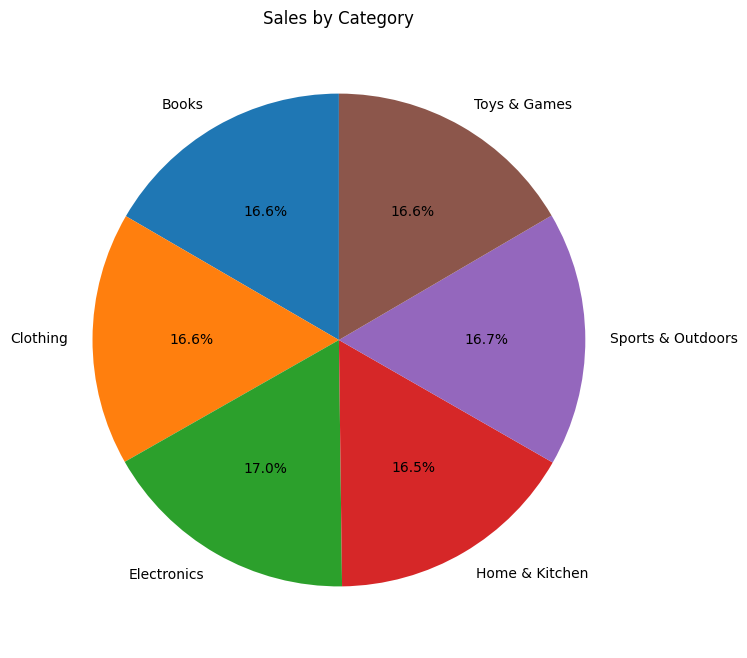

In [31]:
category_sales = (
    df.groupby('Category', as_index=False)['TotalAmount']
      .sum()
)

plt.figure(figsize=(8,8))

plt.pie(
    category_sales['TotalAmount'],
    labels=category_sales['Category'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Sales by Category")

plt.show()

## Line Chart – Monthly Sales Trend
It helps identify seasonal patterns, peak sales months, and periods of lower business activity.

C:\Users\Asus\AppData\Local\Temp\ipykernel_14508\1818021488.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Month', as_index=False)['TotalAmount']


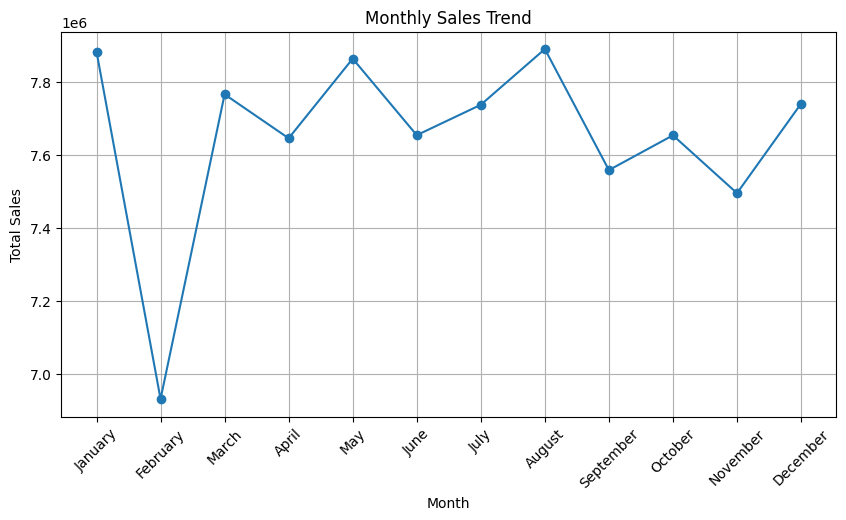

In [32]:
df['Month'] = pd.Categorical(
    df['OrderDate'].dt.month_name(),
    categories=[
        'January','February','March','April','May','June',
        'July','August','September','October','November','December'
    ],
    ordered=True
)

monthly_sales = (
    df.groupby('Month', as_index=False)['TotalAmount']
      .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['TotalAmount'],
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# Conclusion

This project analyzed Amazon India sales transaction data using **Python (Pandas and Matplotlib)** and **Microsoft Excel** to evaluate overall business performance.

The analysis included data cleaning, KPI calculation, sales analysis, customer analysis, payment mode analysis, time-based analysis, and data visualization. Interactive dashboards in Excel and visualizations in Python helped transform raw sales data into meaningful business insights.

## Key Findings

- Calculated key business metrics including Total Sales, Total Orders, Average Sales, and Estimated Profit.
- Identified the highest-performing states, product categories, products, and customers.
- Analyzed customer payment preferences and monthly sales trends.
- Compared sales performance across different states and categories using multi-level analysis.
- Created interactive dashboards and charts for effective business reporting.

## Business Recommendations

1. **Focus on High-Performing Products:** Increase inventory and promotional campaigns for the top-selling products to maximize revenue.

2. **Improve Sales in Low-Performing Regions:** Introduce targeted marketing campaigns, regional discounts, and customer engagement programs in states with lower sales.

3. **Leverage Customer and Payment Insights:** Reward loyal customers and encourage the use of preferred payment methods through cashback offers and exclusive discounts to improve customer retention.

## Overall Outcome

This project demonstrates how data analytics techniques can convert raw business data into actionable insights. By combining Excel dashboards with Python-based analysis, organizations can make informed decisions related to sales performance, inventory management, customer engagement, and business growth.